### Bike Sharing Demand Prediction Using Linear Regression

In [108]:
print("Everything is okey!!!")

Everything is okey!!!


## Objective

Build a **Linear Regression** model to predict the number of bike rentals (`cnt`) using information about the hour, season, weather, working day, and other available features.

### Learning Goals
- Understand a real-world regression problem
- Explore and preprocess the dataset
- Select features and target
- Split data into training and testing sets
- Train a Linear Regression model
- Understand predictions and residuals
- Evaluate the model using **MAE, MSE, RMSE, and R²**
- Visualize actual vs predicted values

> **Important:** This notebook intentionally focuses only on **Linear Regression** so that the complete learning pipeline is easy to understand.


## 1. Problem Statement

A bike-sharing service records hourly rental information along with environmental and calendar-related information.

The main task is:

> **Given the conditions for a particular hour, predict the total number of bike rentals (`cnt`).**

This is a **supervised learning: Regression** problem because:
- Give historical input data.
- The target (`cnt`) is a continuous numerical quantity.


In [109]:
# Importing Dependancies

import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

In [110]:
# Loading Dataset

df = pd.read_csv("D:\\KPMG2\\data\\hour.csv")
df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [111]:
# Last 5 samples

df.tail()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61
17378,17379,2012-12-31,1,1,12,23,0,1,1,1,0.26,0.2727,0.65,0.1343,12,37,49


In [112]:
# Random 5 sample

df.sample(5)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
13161,13162,2012-07-07,3,1,7,14,0,6,0,2,0.96,0.8636,0.30,0.1343,105,203,308
15839,15840,2012-10-27,4,1,10,4,0,6,0,2,0.50,0.4848,0.88,0.1642,1,12,13
11271,11272,2012-04-19,2,1,4,20,0,4,1,1,0.56,0.5303,0.49,0.2239,52,352,404
11122,11123,2012-04-13,2,1,4,15,0,5,1,1,0.54,0.5152,0.28,0.2537,115,237,352
3305,3306,2011-05-22,2,0,5,15,0,0,0,2,0.66,0.6212,0.61,0.1642,110,221,331


In [113]:
# Total samples

df.shape

(17379, 17)

In [114]:
# Different columns

df.columns.to_list()

['instant',
 'dteday',
 'season',
 'yr',
 'mnth',
 'hr',
 'holiday',
 'weekday',
 'workingday',
 'weathersit',
 'temp',
 'atemp',
 'hum',
 'windspeed',
 'casual',
 'registered',
 'cnt']

In [115]:
# Check basic info of dataset 

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.3 MB


In [116]:
# Check missing values
print("Missing values:")
df.isnull().sum()

Missing values:


instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [117]:
# Statistical description of dataset

df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [118]:
# Statistical description of dataset

df.describe().T

,count,mean,std,min,25%,50%,75%,max
instant,17379.0,8690.000000,5017.029500,1.00,4345.5000,8690.0000,13034.5000,17379.0000
season,17379.0,2.501640,1.106918,1.00,2.0000,3.0000,3.0000,4.0000
yr,17379.0,0.502561,0.500008,0.00,0.0000,1.0000,1.0000,1.0000
mnth,17379.0,6.537775,3.438776,1.00,4.0000,7.0000,10.0000,12.0000
hr,17379.0,11.546752,6.914405,0.00,6.0000,12.0000,18.0000,23.0000
holiday,17379.0,0.028770,0.167165,0.00,0.0000,0.0000,0.0000,1.0000
weekday,17379.0,3.003683,2.005771,0.00,1.0000,3.0000,5.0000,6.0000
workingday,17379.0,0.682721,0.465431,0.00,0.0000,1.0000,1.0000,1.0000
weathersit,17379.0,1.425283,0.639357,1.00,1.0000,1.0000,2.0000,4.0000
temp,17379.0,0.496987,0.192556,0.02,0.3400,0.5000,0.6600,1.0000


In [119]:
# Droping "instant"
# instant: record index 

df.drop(columns=['instant'], inplace=True)

In [120]:
df.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [121]:
# Droping ['dteday', 'casual', 'registered']


df.drop(columns=['dteday', 'casual', 'registered'], inplace=True)

In [122]:
df.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


In [123]:
df = df.rename(columns={'weathersit':'weather',
                       'yr':'year',
                       'mnth':'month',
                       'hr':'hour',
                       'hum':'humidity',
                       'cnt':'count'})
df.head()

,season,year,month,hour,holiday,weekday,workingday,weather,temp,atemp,humidity,windspeed,count
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


In [124]:
df['year'].value_counts()

year
1    8734
0    8645
Name: count, dtype: int64

yr : year (0: 2011, 1:2012) 

In [125]:
# Droping "year"


df.drop(columns=['year'], inplace=True)

In [126]:
df.head()

,season,month,hour,holiday,weekday,workingday,weather,temp,atemp,humidity,windspeed,count
0,1,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


In [127]:
# season : season (1:winter, 2:spring, 3:summer, 4:fall) 
# mnth : month ( 1 to 12) 
# hr : hour (0 to 23) 
# holiday : weather day is holiday or not
# weekday : day of the week 
# workingday : if day is neither weekend nor holiday is 1, otherwise is 0. 
# weathersit : 
# 1: Clear, Few clouds, Partly cloudy, Partly cloudy 
# 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist 
# 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds 
# 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog 

# change int columns to category
cols = ['season','month','hour','holiday','weekday','workingday','weather']

for col in cols:
    df[col] = df[col].astype('category')
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   season      17379 non-null  category
 1   month       17379 non-null  category
 2   hour        17379 non-null  category
 3   holiday     17379 non-null  category
 4   weekday     17379 non-null  category
 5   workingday  17379 non-null  category
 6   weather     17379 non-null  category
 7   temp        17379 non-null  float64 
 8   atemp       17379 non-null  float64 
 9   humidity    17379 non-null  float64 
 10  windspeed   17379 non-null  float64 
 11  count       17379 non-null  int64   
dtypes: category(7), float64(4), int64(1)
memory usage: 798.2 KB


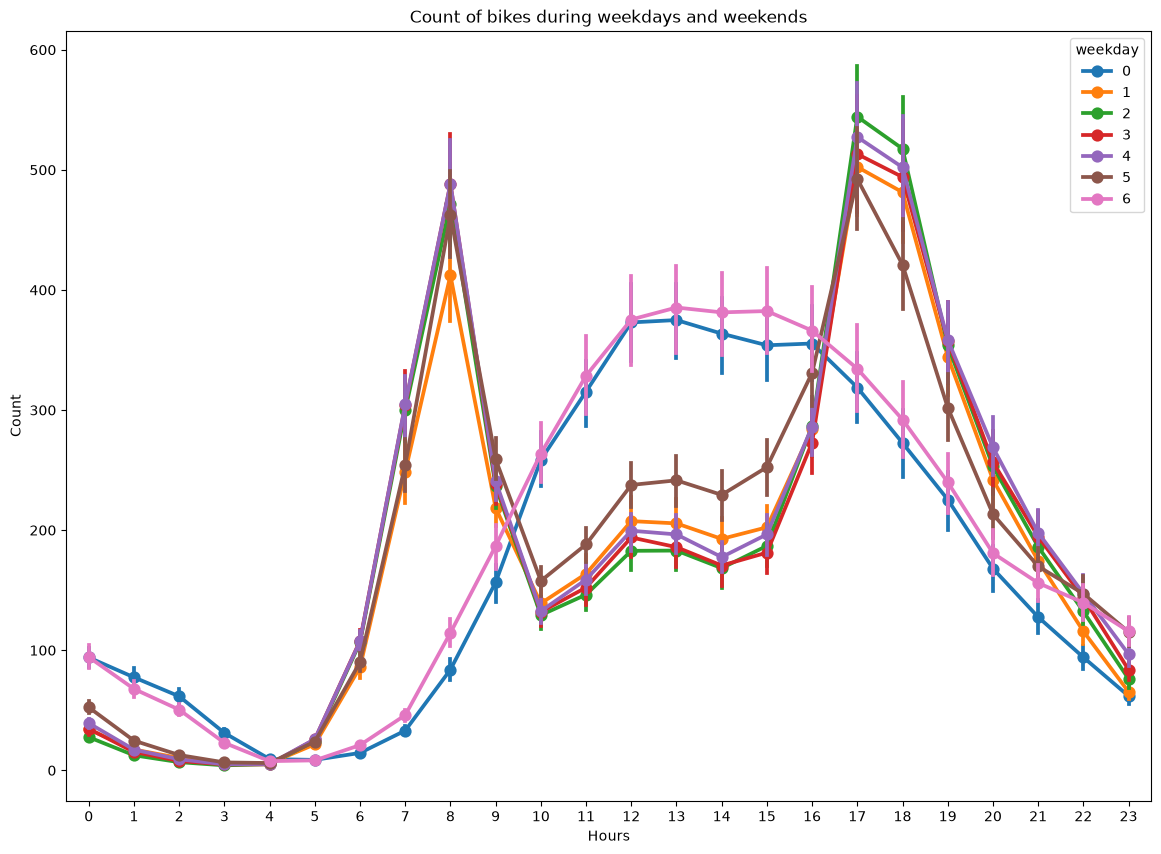

In [128]:
# Data analysis - hourly renting

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(14,10))
sns.pointplot(data=df, x='hour', y='count', hue='weekday')
plt.title("Count of bikes during weekdays and weekends")
plt.xlabel("Hours")
plt.ylabel("Count")
plt.show()

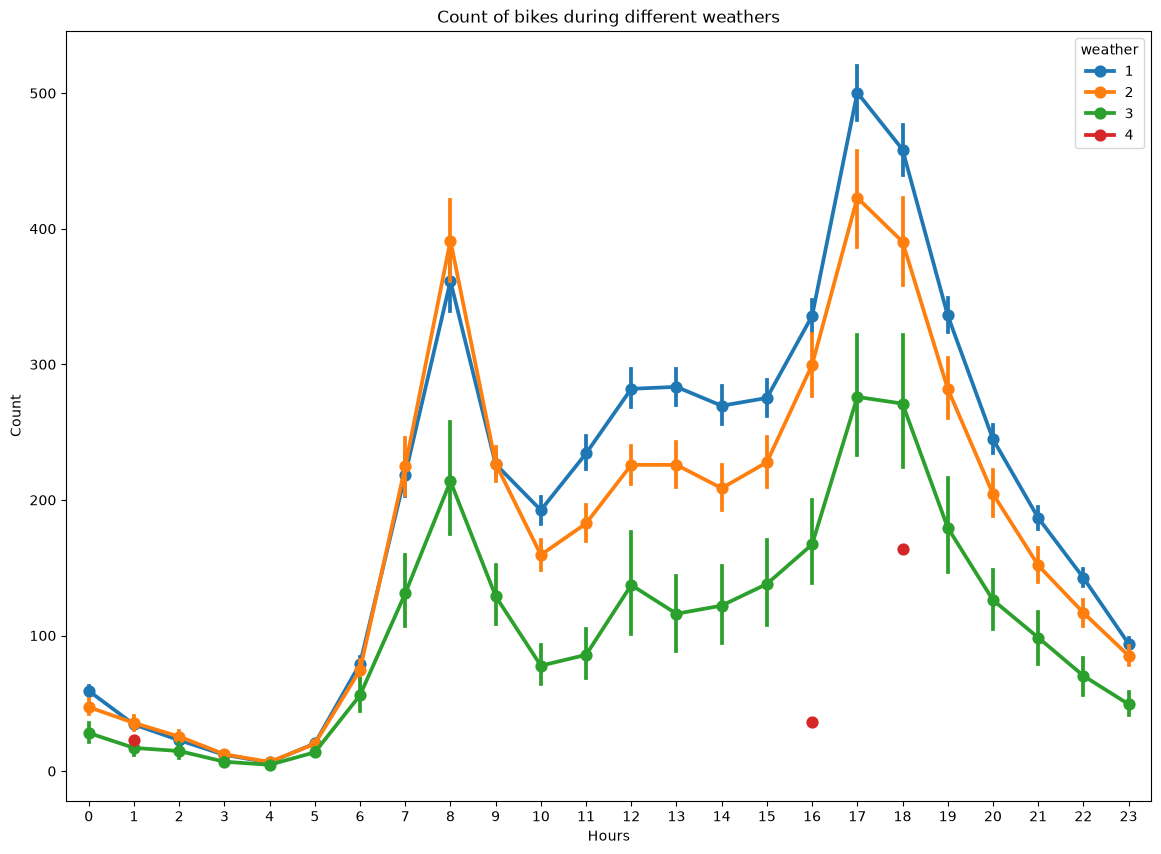

In [129]:
# Data analysis - hourly renting

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(14,10))
sns.pointplot(data=df, x='hour', y='count', hue='weather')
plt.title("Count of bikes during different weathers")
plt.xlabel("Hours")
plt.ylabel("Count")
plt.show()

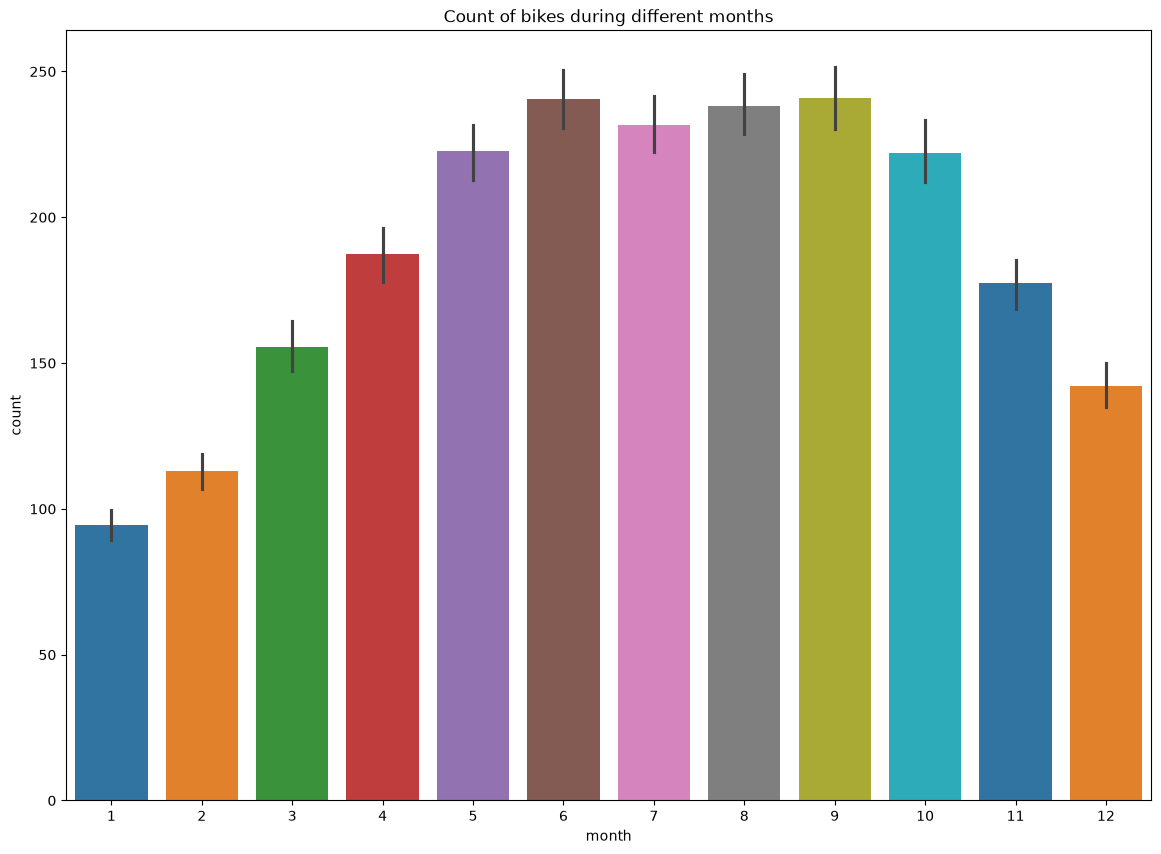

In [130]:
# Data analysis - Count of bikes during different months

plt.figure(figsize=(14,10))
sns.barplot(data=df, x='month', y='count', palette="tab10")
plt.title('Count of bikes during different months')
plt.show()

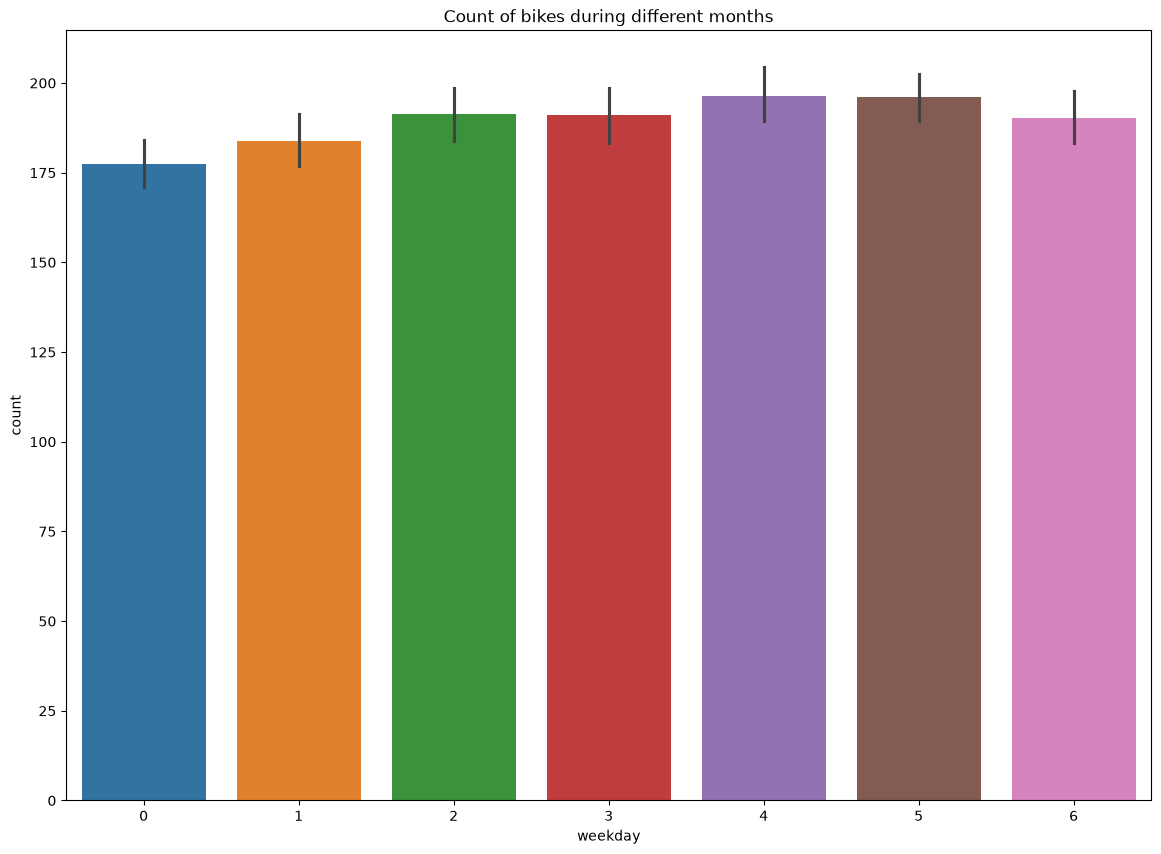

In [131]:
# Data analysis - Count of bikes during different days

plt.figure(figsize=(14,10))
sns.barplot(data=df, x='weekday', y='count', palette="tab10")
plt.title('Count of bikes during different months')
plt.show()

<Figure size 800x600 with 0 Axes>

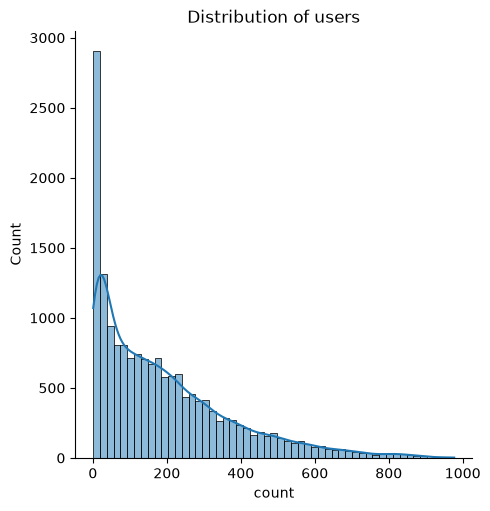

In [132]:
# Users


plt.figure(figsize=(8,6))
sns.displot(df['count'], kde=True)
plt.title('Distribution of users')
plt.show()

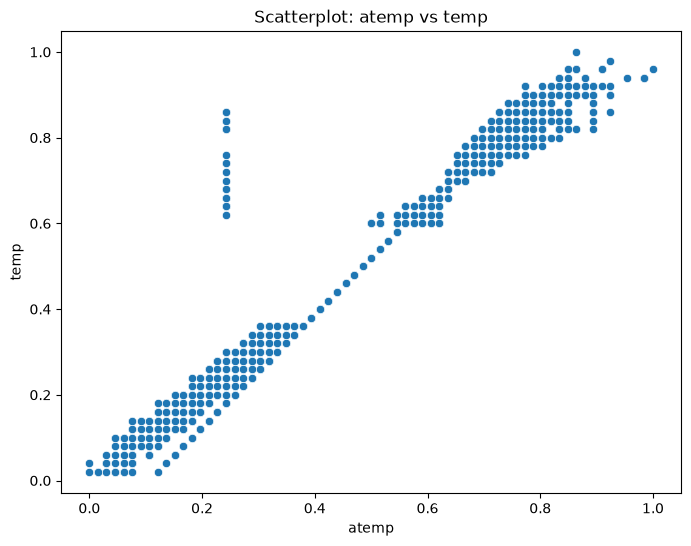

In [133]:
# Analyze atemp and temp

plt.figure(figsize=(8,6))
sns.scatterplot(data = df, x="atemp", y='temp')
plt.title("Scatterplot: atemp vs temp")
plt.show()

In [134]:
# Drop atemp

df.drop(columns=['atemp'], inplace=True)

<Axes: >

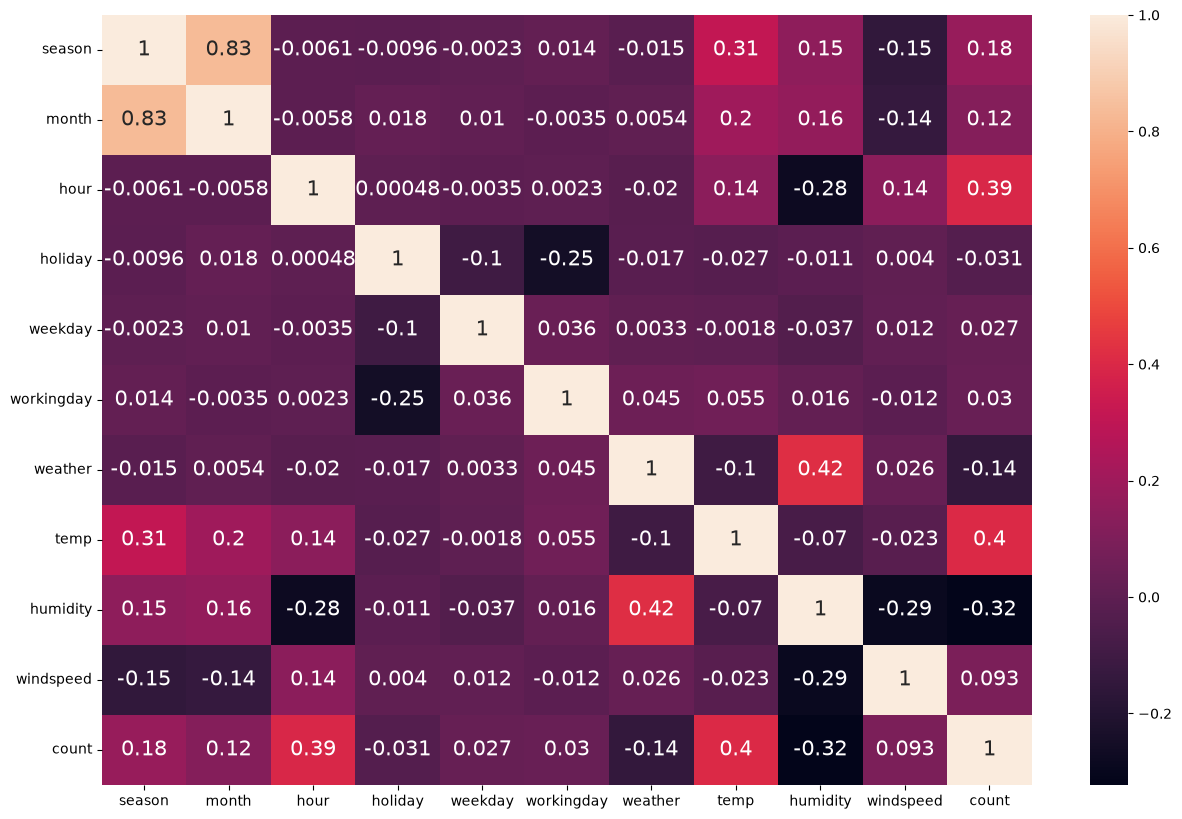

In [135]:
corr = df.corr()
plt.figure(figsize=(15,10))
sns.heatmap(corr, annot=True, annot_kws={'size':15})

In [136]:
# Drop windspeed

df.drop(columns=['windspeed'], inplace=True)

<Axes: >

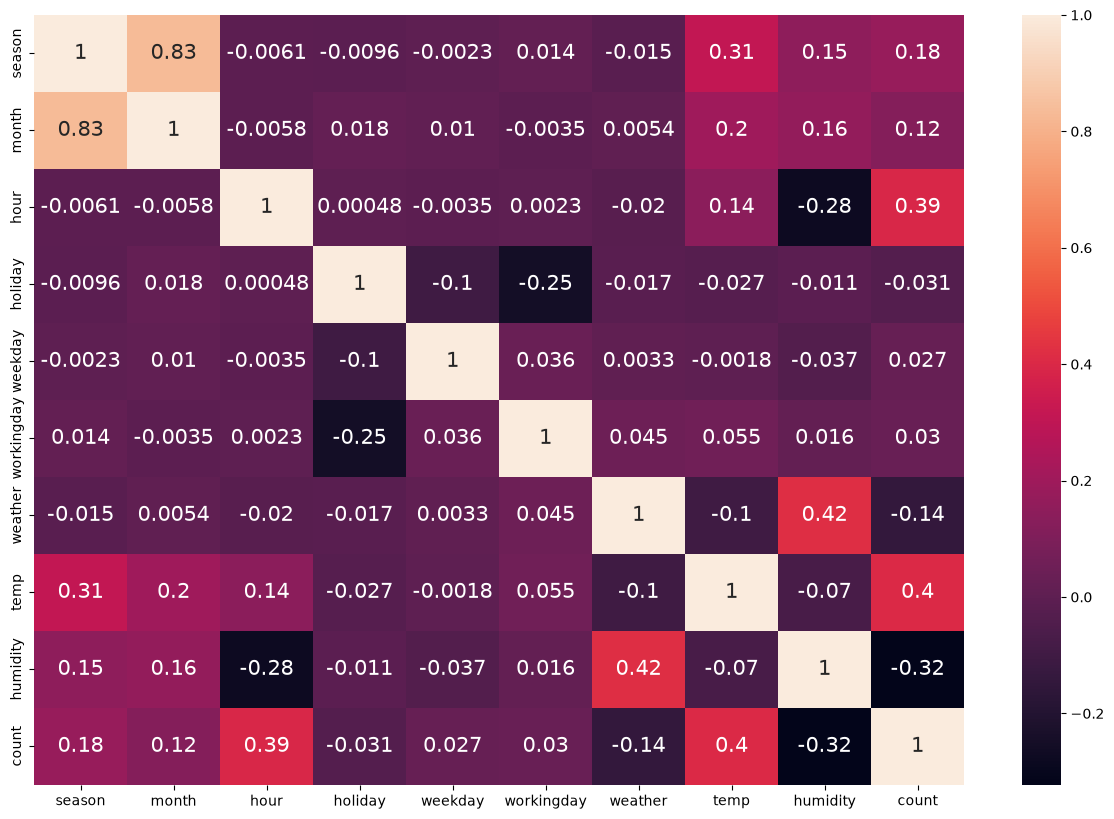

In [137]:
corr = df.corr()
plt.figure(figsize=(15,10))
sns.heatmap(corr, annot=True, annot_kws={'size':15})

In [138]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   season      17379 non-null  category
 1   month       17379 non-null  category
 2   hour        17379 non-null  category
 3   holiday     17379 non-null  category
 4   weekday     17379 non-null  category
 5   workingday  17379 non-null  category
 6   weather     17379 non-null  category
 7   temp        17379 non-null  float64 
 8   humidity    17379 non-null  float64 
 9   count       17379 non-null  int64   
dtypes: category(7), float64(2), int64(1)
memory usage: 527.0 KB


In [139]:
# understanding OHE

d = pd.DataFrame({"Gender": ['Male', 'Female', 'Male','Female']})
d

,Gender
0,Male
1,Female
2,Male
3,Female


In [140]:
pd.get_dummies(d, dtype='int')

,Gender_Female,Gender_Male
0,0,1
1,1,0
2,0,1
3,1,0


In [141]:
pd.get_dummies(d, dtype='int', drop_first=True)

,Gender_Male
0,1
1,0
2,1
3,0


In [ ]:
# Categorical features

print(df.columns)

In [142]:
df_copy = df.copy()

In [143]:
# Categorical features

print([col for col in df.columns.to_list() if df[col].dtype=='category'])

['season', 'month', 'hour', 'holiday', 'weekday', 'workingday', 'weather']


In [144]:
for col in ['season', 'month', 'hour', 'holiday', 'weekday', 'workingday', 'weather']:
    df_copy = pd.get_dummies(df_copy, dtype='int')

In [145]:
# Created a copy of my dataset
df_ohe = df.copy()

In [ ]:
df_ohe.head()

In [146]:
# Applying get dummies to convert categorical into numerical 

cols = ['season', 'month', 'hour', 'holiday', 'weekday', 'workingday', 'weather']

for iter in cols:
    df_ohe = pd.get_dummies(df_ohe, dtype='int', drop_first=True)

df_ohe.head()

,temp,humidity,count,season_2,season_3,season_4,month_2,month_3,month_4,month_5,...,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_1,weather_2,weather_3,weather_4
0,0.24,0.81,16,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0.22,0.80,40,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0.22,0.80,32,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0.24,0.75,13,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,0.24,0.75,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [147]:
df_ohe.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 51 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   temp          17379 non-null  float64
 1   humidity      17379 non-null  float64
 2   count         17379 non-null  int64  
 3   season_2      17379 non-null  int64  
 4   season_3      17379 non-null  int64  
 5   season_4      17379 non-null  int64  
 6   month_2       17379 non-null  int64  
 7   month_3       17379 non-null  int64  
 8   month_4       17379 non-null  int64  
 9   month_5       17379 non-null  int64  
 10  month_6       17379 non-null  int64  
 11  month_7       17379 non-null  int64  
 12  month_8       17379 non-null  int64  
 13  month_9       17379 non-null  int64  
 14  month_10      17379 non-null  int64  
 15  month_11      17379 non-null  int64  
 16  month_12      17379 non-null  int64  
 17  hour_1        17379 non-null  int64  
 18  hour_2        17379 non-null  int64  

In [148]:
# Split data into X and y

X = df_ohe.drop(columns=['count'])
y = df_ohe['count']

In [149]:
X

,temp,humidity,season_2,season_3,season_4,month_2,month_3,month_4,month_5,month_6,...,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_1,weather_2,weather_3,weather_4
0,0.24,0.81,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0.22,0.80,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0.22,0.80,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0.24,0.75,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,0.24,0.75,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,0.26,0.60,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,1,0,0
17375,0.26,0.60,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,1,0,0
17376,0.26,0.60,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
17377,0.26,0.56,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0


In [150]:
y

0         16
1         40
2         32
3         13
4          1
        ... 
17374    119
17375     89
17376     90
17377     61
17378     49
Name: count, Length: 17379, dtype: int64

In [151]:
df_ohe.min(), df_ohe.max()

(temp            0.02
 humidity        0.00
 count           1.00
 season_2        0.00
 season_3        0.00
 season_4        0.00
 month_2         0.00
 month_3         0.00
 month_4         0.00
 month_5         0.00
 month_6         0.00
 month_7         0.00
 month_8         0.00
 month_9         0.00
 month_10        0.00
 month_11        0.00
 month_12        0.00
 hour_1          0.00
 hour_2          0.00
 hour_3          0.00
 hour_4          0.00
 hour_5          0.00
 hour_6          0.00
 hour_7          0.00
 hour_8          0.00
 hour_9          0.00
 hour_10         0.00
 hour_11         0.00
 hour_12         0.00
 hour_13         0.00
 hour_14         0.00
 hour_15         0.00
 hour_16         0.00
 hour_17         0.00
 hour_18         0.00
 hour_19         0.00
 hour_20         0.00
 hour_21         0.00
 hour_22         0.00
 hour_23         0.00
 holiday_1       0.00
 weekday_1       0.00
 weekday_2       0.00
 weekday_3       0.00
 weekday_4       0.00
 weekday_5

In [152]:
# Split data into train and test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 13903
Testing samples : 3476


In [153]:
# Model building

from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [154]:
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [155]:
model.intercept_

np.float64(-32.733623173536046)

In [156]:
model.coef_

array([ 2.78829219e+02, -1.04327633e+02,  3.40138247e+01,  2.88219056e+01,
        7.03333444e+01, -2.06218348e+00,  4.33863472e+00, -3.22907591e+00,
        6.25426592e+00, -1.32422638e+01, -3.50976026e+01, -1.47812434e+01,
        1.89028077e+01,  3.10831157e+00, -1.92940139e+01, -1.21785849e+01,
       -1.71627846e+01, -2.69517968e+01, -3.47095729e+01, -3.64972167e+01,
       -2.04424633e+01,  3.63044487e+01,  1.72888445e+02,  3.16725285e+02,
        1.63030637e+02,  1.04723211e+02,  1.25232359e+02,  1.66805787e+02,
        1.60302762e+02,  1.36776729e+02,  1.44697646e+02,  2.12124388e+02,
        3.69246134e+02,  3.31298021e+02,  2.27420845e+02,  1.53560937e+02,
        1.04727240e+02,  6.92913679e+01,  2.97665287e+01, -1.67576319e+01,
       -3.80683551e+00, -3.50551600e+00,  2.56345431e-01, -2.19657427e+00,
        3.62662599e+00,  1.44680367e+01,  1.11316775e+01, -7.49195851e+00,
       -6.49905869e+01, -1.13514918e+02])

In [157]:
len(model.coef_)

50

In [158]:
y_pred = model.predict(X_test)

In [159]:
y_pred

array([419.62981439, 124.40752986,  48.88365197, ..., 135.26078219,
       155.97019838, 298.57295281], shape=(3476,))

In [160]:
# Model Performence
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 78.06
MSE  : 11840.11
RMSE : 108.81
R²   : 0.6261


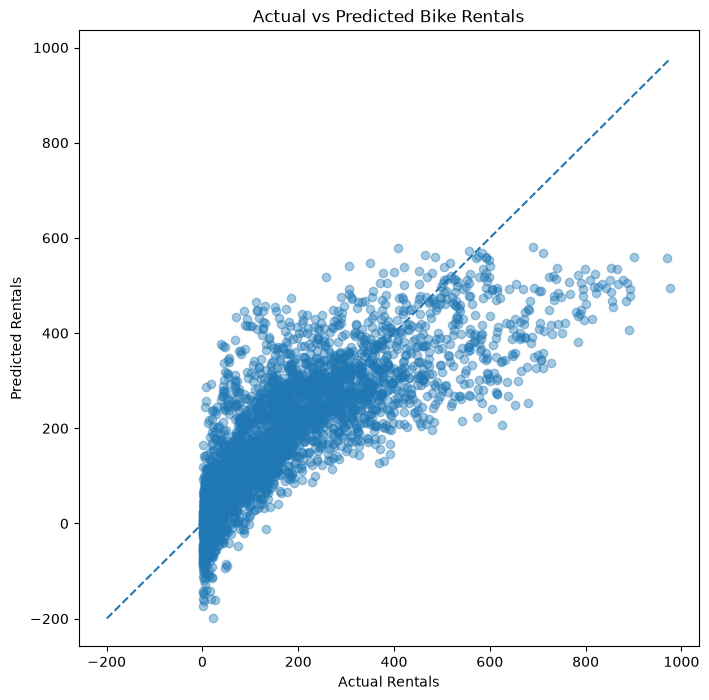

In [161]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.4)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.xlabel("Actual Rentals")
plt.ylabel("Predicted Rentals")
plt.title("Actual vs Predicted Bike Rentals")
plt.show()

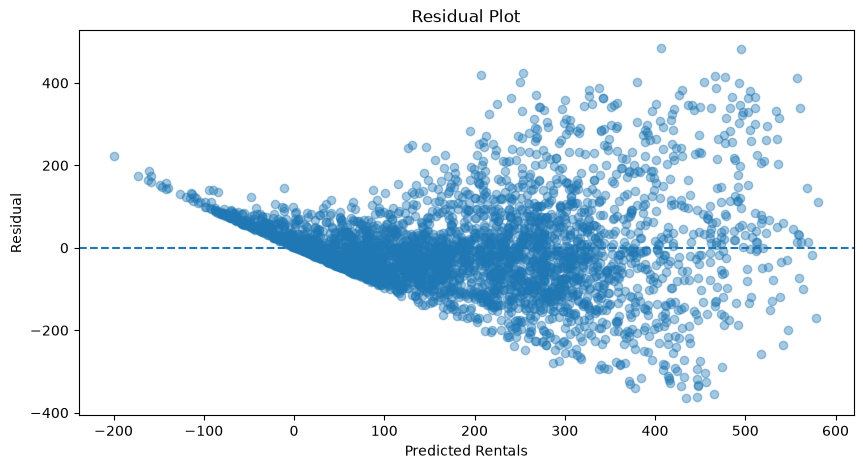

In [162]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Rentals")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()